In [1]:
import numpy as np
import pickle
from scipy.optimize import fsolve
from GW_spectrum_SNR import *
from PLIs.GW_detectors import *
from Veff_Daniel import EffectivePotential

from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import os
from matplotlib import rcParams
from matplotlib import rc,cm
from matplotlib.colors import LogNorm
import matplotlib
#os.environ['PATH'] = '/usr/local/texlive/2021/bin/universal-darwin/'
rcParams['font.size'] = 24
rc('text', usetex=True)

thick_size=16
label_size=20


In [2]:
muARES_spec = pickle.load(open('PLIs/muares_spec.p','rb'))

In [3]:
f_muARES, Omega_muARES = muARES_spec

Omega_ares_inter = interp1d(f_muARES, Omega_muARES)

# Experiment params

In [4]:
'''
SKA
'''
SKA = GW_detectors('ska')
SKA_spec = SKA.spectral_density
t_obs = 20 * 365 * 24 * 3600
fmin = 1/t_obs
fmax = 1/(14 * 24 * 3600)* 1e-1
rho_thresh = 4

In [5]:
'''
LISA
'''
lisa = GW_detectors('lisa')
lisa_spec = lisa.spectral_density
t_obs_lisa = 4 * 365 * 24 * 3600
fmin_lisa = 1e-7
fmax_lisa = 1e0 * 1e-1
rho_thresh_lisa = 10

In [6]:
'''
BBO
'''
bbo = GW_detectors('bbo')
bbo_spec = bbo.spectral_density
t_obs_bbo = 4 * 365 * 24 * 3600
fmin_bbo = 1e-3
fmax_bbo = 1e2 * 0.01
rho_thresh_bbo = 10

In [7]:
'''
ET
'''
et = GW_detectors('et')
et_spec = et.spectral_density
t_obs_et = 5 * 365 * 24 * 3600
fmin_et = 1
fmax_et = 1e3 * 0.01
rho_thresh_et = 5

In [8]:
'''
muARES
'''
ARES_spec = Omega_ares_inter
t_obs_ares = 7 * 365 * 24 * 3600
fmin_ares = min(f_muARES)
fmax_ares = max(f_muARES) * 0.01
rho_thresh_ares = 10

In [9]:
'''
decigo
'''
decigo = GW_detectors('decigo')
decigo_spec = decigo.spectral_density
t_obs_decigo = 4 * 365 * 24 * 3600
fmin_decigo = 1e-3
fmax_decigo = 1e2 * 0.01
rho_thresh_decigo = 10

# COMPUTE LISA

In [10]:
g_list = np.logspace(-4, -1, 50)
m_list =  np.logspace(4,8,50)

counter1 = 0
SNRs = []
for g in g_list:
    print(counter1)
    this_SNR = []
    for m in m_list:
        model = EffectivePotential(g, m, vh_qcd=0.1)
        model.interpolations()

        m_over_H = model.m_over_H()
        T_rh = model.find_T_vac() # COMPUTE T_rh from model parameters
        H_star = model.Hubble(T_rh) # COMPUTE H_* from model parameters
        test = GW_analysis(m_over_H,H_star,T_rh)
        SNR = test.SNR_auto(t_obs_lisa,lisa_spec,fmin_lisa,fmax_lisa)
        this_SNR.append(SNR)
    SNRs.append(this_SNR)
    counter1 += 1
print(SNR)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
3.373422558263048e-06


In [11]:
X,Y=np.meshgrid(m_list,g_list)

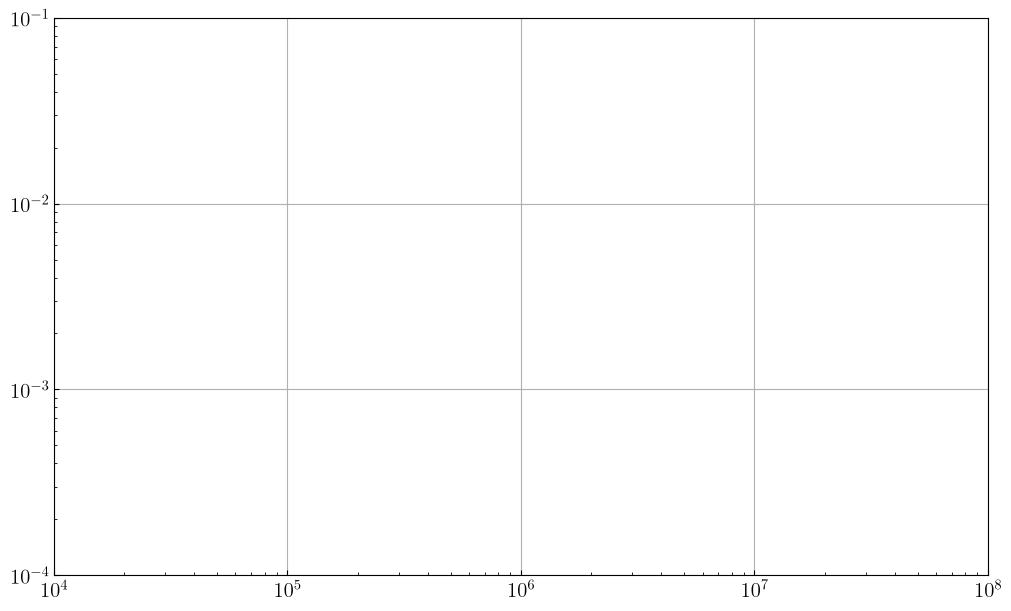

In [12]:
fig,ax=plt.subplots(figsize=(10,6))
CS2 = ax.contour(X, Y, SNRs, levels=[rho_thresh_lisa], colors='r',linewidths=4)
#CS2 = ax.contour(X2, Y2, SNR2, levels=[rho_thresh_lisa], colors='b',linewidths=4)

ax.set_yscale('log')
ax.set_xscale('log')
#ax.set_ylim(1e-18,1e-13)
#ax.set_xlim(1e-30,1e12)
#ax.axvline(1e-14)
#ax.scatter(5e-11,2e-17)
#ax.axvline(1e4*1e-9)

# COMPUTE BBO

In [13]:
#g_list = LIST OF g_BL
#m_list = LIST OF m_ZPrime

counter1 = 0
SNRs = []
for g in g_list:
    print(counter1)
    this_SNR = []
    for m in m_list:
        #m_over_H = COMPUTE ratio of |m_QCD/H| from model parameters
        #H_star = COMPUTE H_* from model parameters
        #T_rh = COMPUTE T_rh from model parameters
        test = GW_analysis(m_over_H,H_star,T_rh)
        SNR = test.SNR(t_obs_bbo,bbo_spec,fmin_bbo,fmax_bbo)
        this_SNR.append(SNR)
    SNRs.append(this_SNR)
    counter1 += 1

X,Y=np.meshgrid(m_list,g_list)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49


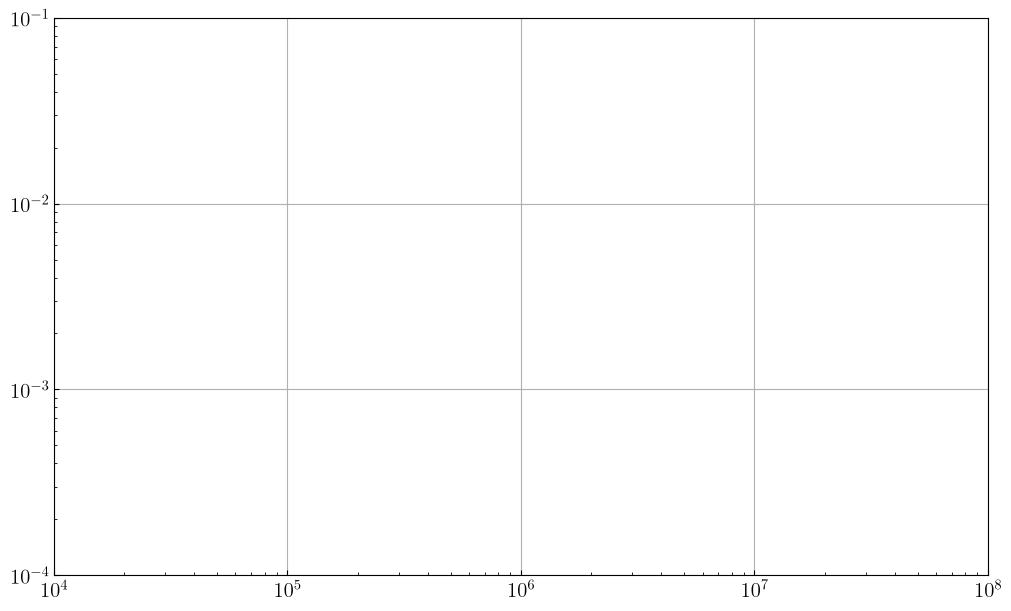

In [14]:
fig,ax=plt.subplots(figsize=(10,6))
#ax.contour(X1, Y1, SNR1, levels=[rho_thresh_bbo], colors='b',linewidths=3)
ax.contour(X, Y, SNRs, levels=[rho_thresh_bbo], colors='r',linewidths=4)

ax.set_yscale('log')
ax.set_xscale('log')
#ax.set_ylim(2e-18,1e-11)
#ax.set_xlim(1e-30,1e12)
#ax.axvline(1e-14)
#ax.scatter(100*1e-9,1e-16)
#ax.axvline(1e4*1e-9)

# COMPUTE ET

In [15]:
#g_list = LIST OF g_BL
#m_list = LIST OF m_ZPrime

counter1 = 0
SNRs = []
for g in g_list:
    print(counter1)
    this_SNR = []
    for m in m_list:
        #m_over_H = COMPUTE ratio of |m_QCD/H| from model parameters
        #H_star = COMPUTE H_* from model parameters
        #T_rh = COMPUTE T_rh from model parameters
        test = GW_analysis(m_over_H,H_star,T_rh)
        SNR = test.SNR(t_obs_et,et_spec,fmin_et,fmax_et)
        this_SNR.append(SNR)
    SNRs.append(this_SNR)
    counter1 += 1

X,Y=np.meshgrid(m_list,g_list)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49


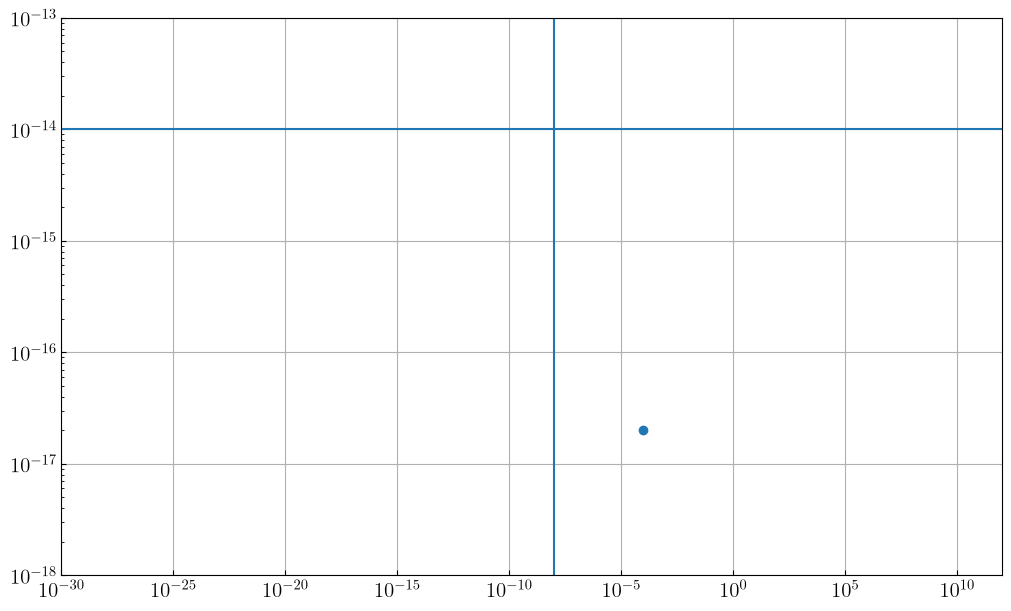

In [16]:
fig,ax=plt.subplots(figsize=(10,6))
ax.contour(X, Y, SNRs, levels=[rho_thresh_et], colors='b',linewidths=3)
#ax.contour(X1, Y1, SNR1, levels=[rho_thresh_et], colors='r',linewidths=4)

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylim(1e-18,1e-13)
ax.set_xlim(1e-30,1e12)
ax.scatter(1e5*1e-9,2e-17)
ax.axvline(1e-8)
ax.axhline(1e-14)

# COMPUTE muARES

In [17]:
#g_list = LIST OF g_BL
#m_list = LIST OF m_ZPrime

counter1 = 0
SNRs = []
for g in g_list:
    print(counter1)
    this_SNR = []
    for m in m_list:
        #m_over_H = COMPUTE ratio of |m_QCD/H| from model parameters
        #H_star = COMPUTE H_* from model parameters
        #T_rh = COMPUTE T_rh from model parameters
        test = GW_analysis(m_over_H,H_star,T_rh)
        SNR = test.SNR_auto(t_obs_ares,ARES_spec,fmin_ares,fmax_ares)
        this_SNR.append(SNR)
    SNRs.append(this_SNR)
    counter1 += 1

X,Y=np.meshgrid(m_list,g_list)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49


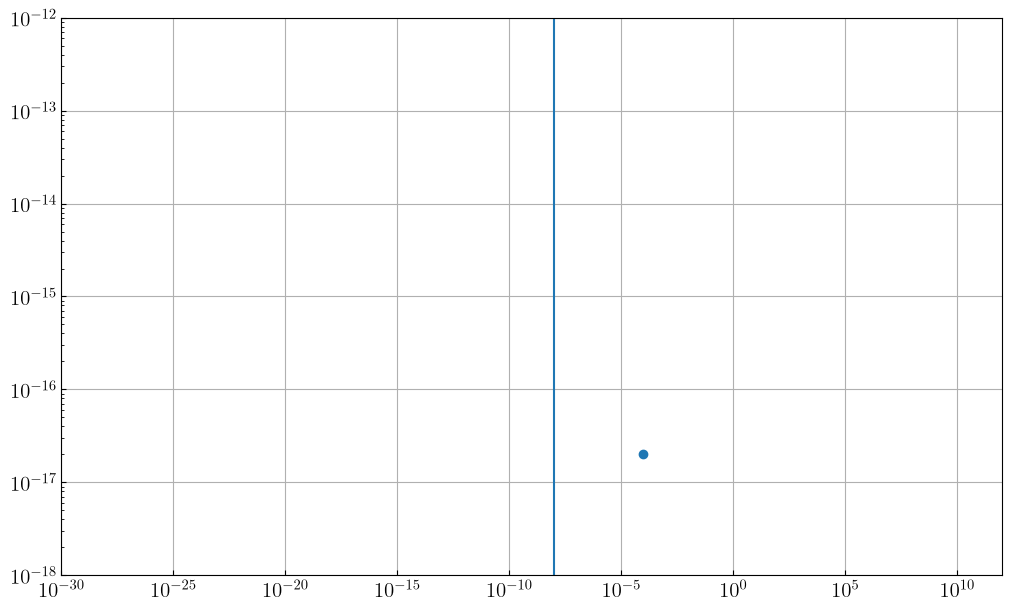

In [18]:
fig,ax=plt.subplots(figsize=(10,6))
ax.contour(X, Y, SNRs, levels=[rho_thresh_ares], colors='b',linewidths=3)
#ax.contour(X1, Y1, SNR1, levels=[rho_thresh_et], colors='r',linewidths=4)

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylim(1e-18,1e-12)
ax.set_xlim(1e-30,1e12)
ax.scatter(1e5*1e-9,2e-17)
ax.axvline(1e-8)

# COMPUTE DECIGO

In [19]:
#g_list = LIST OF g_BL
#m_list = LIST OF m_ZPrime

counter1 = 0
SNRs = []
for g in g_list:
    print(counter1)
    this_SNR = []
    for m in m_list:
        #m_over_H = COMPUTE ratio of |m_QCD/H| from model parameters
        #H_star = COMPUTE H_* from model parameters
        #T_rh = COMPUTE T_rh from model parameters
        test = GW_analysis(m_over_H,H_star,T_rh)
        SNR = test.SNR(t_obs_decigo,decigo_spec,fmin_decigo,fmax_decigo)
        this_SNR.append(SNR)
    SNRs.append(this_SNR)
    counter1 += 1

X,Y=np.meshgrid(m_list,g_list)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
